# Analysis

#### 1. Imports

In [1]:
import pandas as pd
import ast
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.stats import chi2_contingency
import numpy as np

#### 2. Loading the lemmatized corpus

In [8]:
df = pd.read_csv("/Users/sophiehamann/master-thesis-code/data/processed/09_h1_lemmatized.csv")
df["tokens"] = df["tokens"].apply(ast.literal_eval)

#### 3. Extracting the issue number and assign the volume group
(Diachronic segmentation)

In [10]:
def get_issue_number(filepath):
    match = re.search(r"heresies_(\d+)_combined", filepath)
    return int(match.group(1)) if match else None

def get_volume(issue_nr):
    if issue_nr <= 4:
        return "Vol1_1977-1978"
    elif issue_nr <= 8:
        return "Vol2_1978-1979"
    elif issue_nr <= 12:
        return "Vol3_1980-1981"
    elif issue_nr <= 16:
        return "Vol4_1981-1983"
    elif issue_nr <= 20:
        return "Vol5_1984-1985"
    elif issue_nr <= 24:
        return "Vol6_1987-1989"
    elif issue_nr <= 27:
        return "Vol7_1990-1993"
    else:
        return None

df["issue"]  = df["source_file"].apply(get_issue_number)
df["volume"] = df["issue"].apply(get_volume)

print(df["volume"].value_counts())
print(f"Total issues loaded: {df['issue'].nunique()}")
print(f"Issues present: {sorted(df['issue'].unique())}")

volume
Vol2_1978-1979    4376
Vol1_1977-1978    3706
Vol3_1980-1981    3592
Vol4_1981-1983    2868
Vol6_1987-1989    2440
Vol5_1984-1985    2384
Vol7_1990-1993    1267
Name: count, dtype: int64
Total issues loaded: 27
Issues present: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]


#### 4. Create one text string per volume

In [11]:
# join all tokens per volume into one string
# this is needed for TF-IDF and keyword analysis

volume_texts = df.groupby("volume")["tokens"].apply(
    lambda x: " ".join([token for tokens in x for token in tokens])
)

print(volume_texts.index.tolist())

['Vol1_1977-1978', 'Vol2_1978-1979', 'Vol3_1980-1981', 'Vol4_1981-1983', 'Vol5_1984-1985', 'Vol6_1987-1989', 'Vol7_1990-1993']


#### 5. Relative Frequency for key feminist terms
Using this: https://www.geeksforgeeks.org/python/python-frequency-of-each-character-in-string/


This compares the same words in each diachronically segmented part. The words being looked for are pre-defined. these may need to change!

Here, the loop counts the raw occurrences and then converts these to relative frequency per 1,000 words. So if "woman" appears 80 times in a volume of 10,000 tokens, its gets (80/10000)*1000 = 8.0.
This is done because the volumes do have different sizes, so raw counts could be misleading. 

In [16]:
# these are your expected keywords from your notes
key_terms = ["body", "woman", "difference", "language", 
             "representation", "identity", "power", "sexuality",
             "nature", "culture", "construction", "discourse"]

results = []

for volume, text in volume_texts.items():
    tokens = text.split()
    total  = len(tokens)
    for term in key_terms:
        freq    = tokens.count(term)
        rel_freq = (freq / total) * 1000   # per 1000 words
        results.append({
            "volume": volume,
            "term":   term,
            "relative_frequency": rel_freq
        })

df_freq = pd.DataFrame(results)
print(df_freq.head(50))

            volume            term  relative_frequency
0   Vol1_1977-1978            body            1.389728
1   Vol1_1977-1978           woman           25.317221
2   Vol1_1977-1978      difference            0.362538
3   Vol1_1977-1978        language            0.362538
4   Vol1_1977-1978  representation            0.120846
5   Vol1_1977-1978        identity            0.181269
6   Vol1_1977-1978           power            1.087613
7   Vol1_1977-1978       sexuality            0.241692
8   Vol1_1977-1978          nature            0.483384
9   Vol1_1977-1978         culture            1.691843
10  Vol1_1977-1978    construction            0.120846
11  Vol1_1977-1978       discourse            0.000000
12  Vol2_1978-1979            body            1.479290
13  Vol2_1978-1979           woman           21.388067
14  Vol2_1978-1979      difference            0.801282
15  Vol2_1978-1979        language            0.061637
16  Vol2_1978-1979  representation            0.493097
17  Vol2_1

#### 6. Line Chart of Key Terms over time
Using this: https://www.geeksforgeeks.org/python/line-chart-in-matplotlib-python/

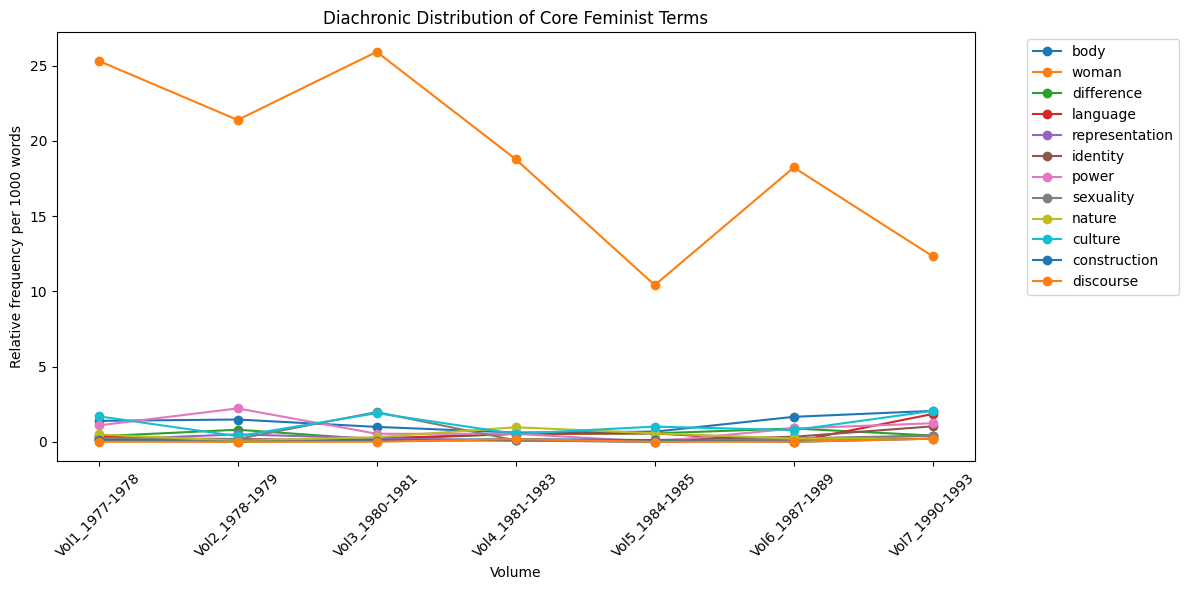

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))

for term in key_terms:
    term_data = df_freq[df_freq["term"] == term]
    ax.plot(term_data["volume"], term_data["relative_frequency"], marker="o", label=term)

ax.set_xlabel("Volume")
ax.set_ylabel("Relative frequency per 1000 words")
ax.set_title("Diachronic Distribution of Core Feminist Terms")
ax.legend(bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph1_frequency.png")
plt.show()

##### The following visualization post has been written with the help of Claude. 
You can find the prompt here: /Users/sophiehamann/master-thesis-code/notebooks/AI_prompts/h1_12_analysis_viz_prompt.txt

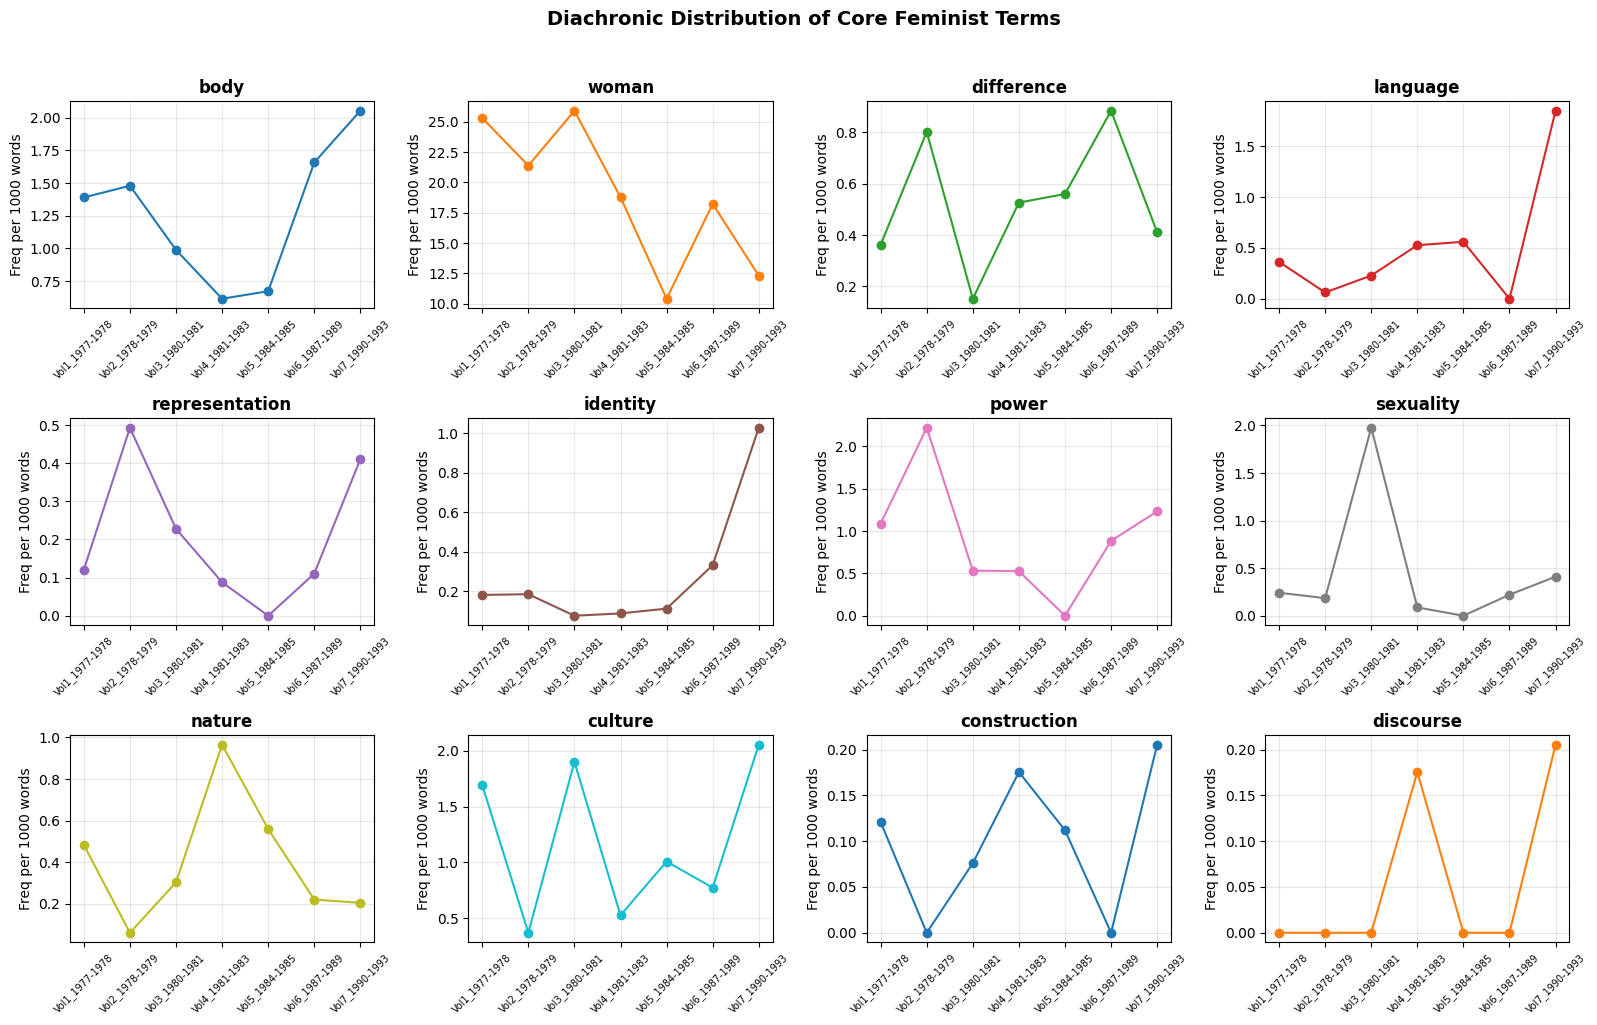

In [19]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, term in enumerate(key_terms):
    ax = axes[i]
    term_data = df_freq[df_freq["term"] == term]
    ax.plot(term_data["volume"], term_data["relative_frequency"], marker="o", color=f"C{i}")
    ax.set_title(term, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Freq per 1000 words")
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.grid(True, alpha=0.3)

# Hide any unused subplots
for j in range(len(key_terms), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Diachronic Distribution of Core Feminist Terms", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph1_frequency_small_multiples.png", bbox_inches="tight")
plt.show()

##### The following visualization, the y axis is the same everywhere to avoid confusion.

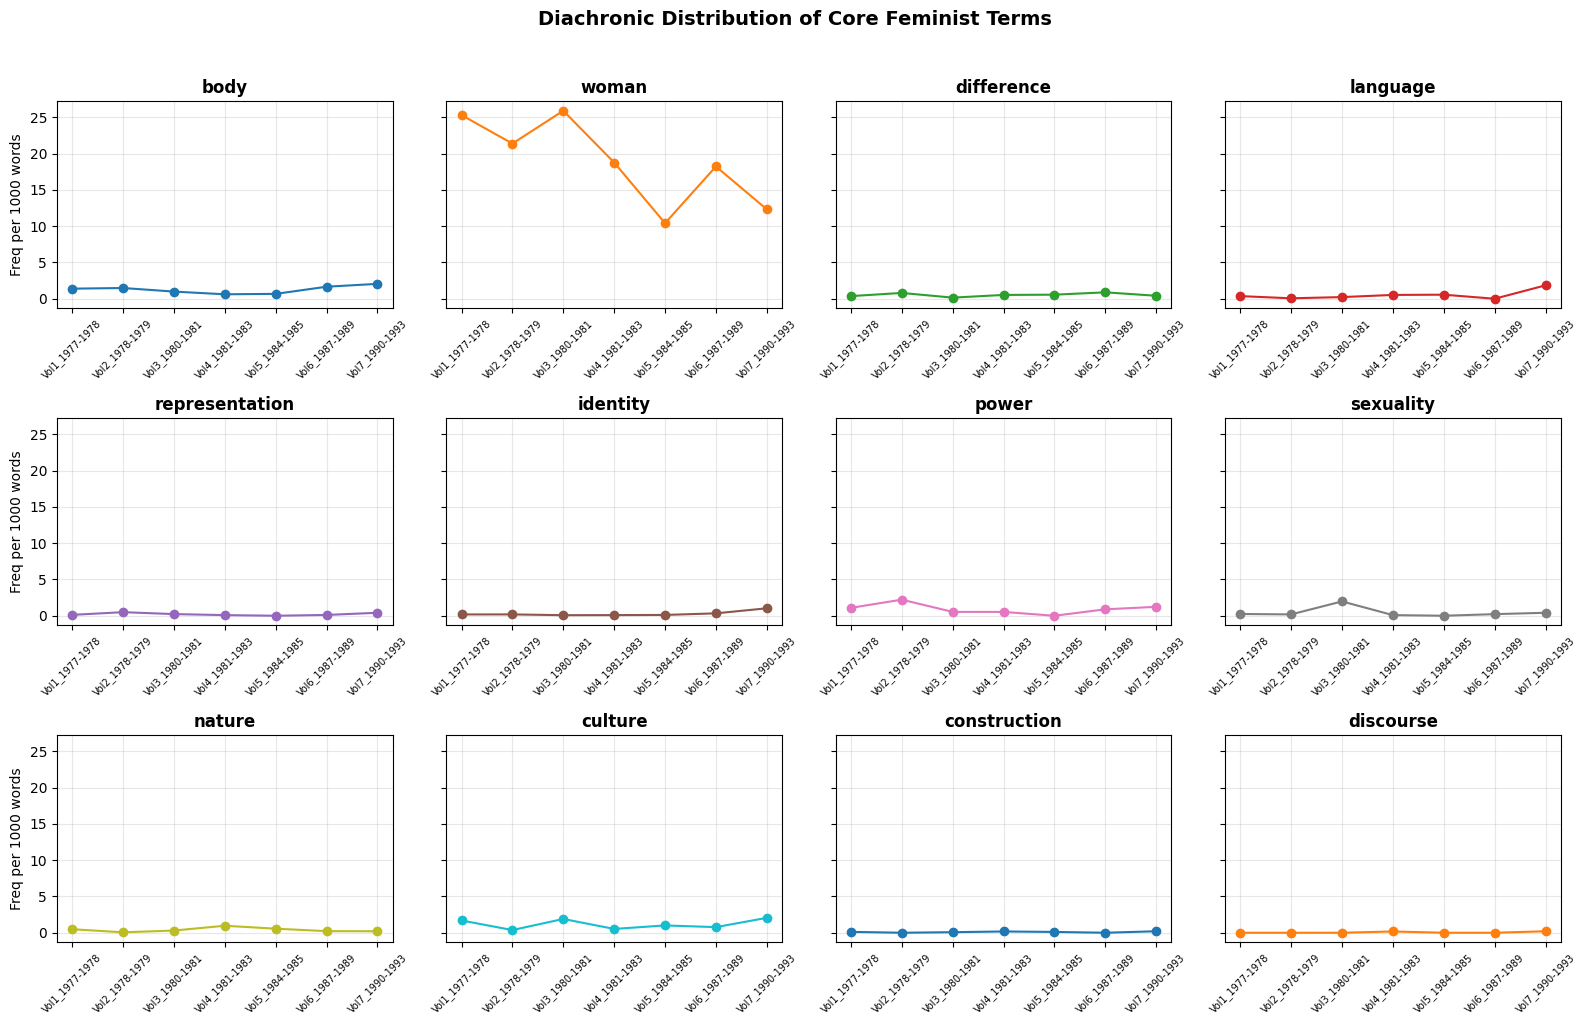

In [20]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharey=True)
axes = axes.flatten()

for i, term in enumerate(key_terms):
    ax = axes[i]
    term_data = df_freq[df_freq["term"] == term]
    ax.plot(term_data["volume"], term_data["relative_frequency"], marker="o", color=f"C{i}")
    ax.set_title(term, fontweight="bold")
    ax.set_ylabel("Freq per 1000 words" if i % 4 == 0 else "")
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.grid(True, alpha=0.3)

for j in range(len(key_terms), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Diachronic Distribution of Core Feminist Terms", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph1_frequency_small_multiples_shared_y.png", bbox_inches="tight")
plt.show()

#### 7. TF-IDF per volume
Using [this documentation for help.](https://www.geeksforgeeks.org/machine-learning/understanding-tf-idf-term-frequency-inverse-document-frequency/)

This cell finds the most distinctive words per volume. Meaning it doe not just find the most frequent words, but the ones that characterize each volume compared to the other volumes.

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=50)
tfidf_matrix = vectorizer.fit_transform(volume_texts.values)
feature_names = vectorizer.get_feature_names_out()

df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=volume_texts.index,
    columns=feature_names
)

print(df_tfidf)

                    also       art    artist     begin     black     child  \
volume                                                                       
Vol1_1977-1978  0.079935  0.308083  0.091592  0.053290  0.008327  0.069943   
Vol2_1978-1979  0.050662  0.090065  0.078807  0.073178  0.110705  0.037527   
Vol3_1980-1981  0.060850  0.115180  0.043464  0.041291  0.073889  0.045638   
Vol4_1981-1983  0.061864  0.118348  0.045725  0.078002  0.239386  0.053795   
Vol5_1984-1985  0.070996  0.137815  0.045938  0.096053  0.079348  0.066819   
Vol6_1987-1989  0.070606  0.222408  0.091787  0.088257  0.014121  0.052954   
Vol7_1990-1993  0.078791  0.350977  0.229210  0.143256  0.071628  0.093116   

                    come     could       day      feel  ...       use  \
volume                                                  ...             
Vol1_1977-1978  0.094923  0.054955  0.048294  0.048294  ...  0.091592   
Vol2_1978-1979  0.088189  0.073178  0.052538  0.043156  ...  0.060044   
Vol3_

"child" peaks strongly in Vol4 (0.239) — worth investigating

"artist" is high in Vol1 and Vol7 — a return to art focus?

"black" grows from Vol1 (0.053) to Vol7 (0.143) — suggests increasing attention to race over time

#### 8. Keyword comparison table

Printing the 20 most distinctive words for each volume ranked by their TF-IDF score. 

In [23]:
# show top 10 distinctive terms per volume
for volume in df_tfidf.index:
    print(f"\nTop keywords for {volume}:")
    print(df_tfidf.loc[volume].sort_values(ascending=False).head(10))


Top keywords for Vol1_1977-1978:
woman       0.707759
art         0.308083
not         0.241471
work        0.236475
one         0.168197
make        0.141552
time        0.121568
feminist    0.116572
mother      0.114907
like        0.109911
Name: Vol1_1977-1978, dtype: float64

Top keywords for Vol2_1978-1979:
woman    0.662355
work     0.270196
not      0.242051
one      0.232669
group    0.217658
time     0.159491
say      0.127593
year     0.121963
make     0.121963
know     0.116334
Name: Vol2_1978-1979, dtype: float64

Top keywords for Vol3_1980-1981:
woman       0.762798
not         0.249920
one         0.195589
work        0.158645
feminist    0.134739
say         0.130393
time        0.117354
art         0.115180
like        0.115180
make        0.115180
Name: Vol3_1980-1981, dtype: float64

Top keywords for Vol4_1981-1983:
woman     0.583671
not       0.268973
black     0.239386
work      0.217868
film      0.193660
one       0.190971
say       0.158694
people    0.150625
g

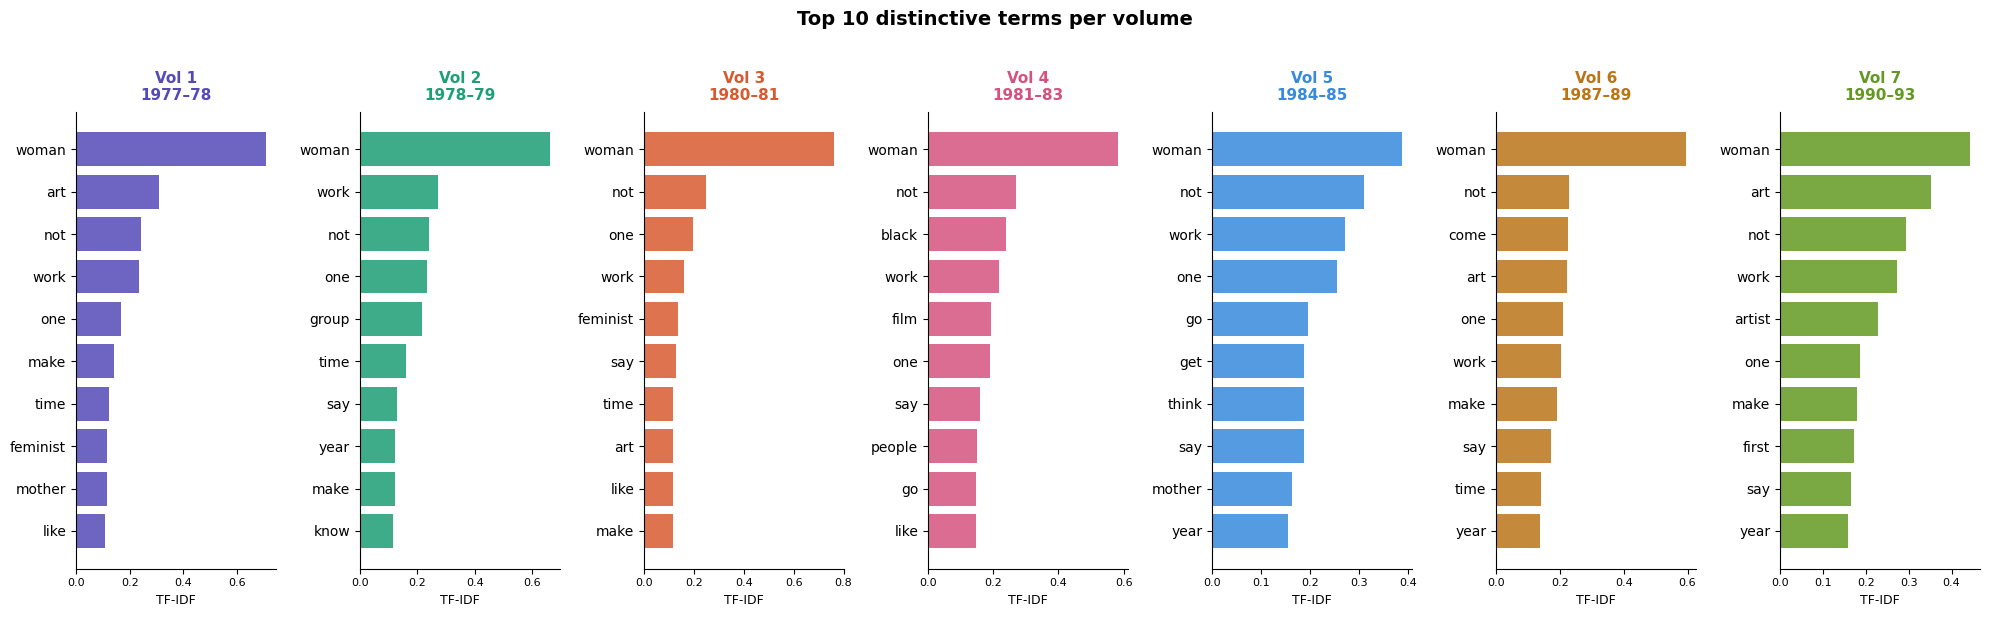

In [26]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 7, figsize=(20, 6), sharey=False)

colors = ["#534AB7", "#1D9E75", "#D85A30", "#D4537E", "#378ADD", "#BA7517", "#639922"]
labels = ["Vol 1\n1977–78", "Vol 2\n1978–79", "Vol 3\n1980–81", "Vol 4\n1981–83",
          "Vol 5\n1984–85", "Vol 6\n1987–89", "Vol 7\n1990–93"]

for i, (volume, ax) in enumerate(zip(df_tfidf.index, axes)):
    top10 = df_tfidf.loc[volume].sort_values(ascending=False).head(10)
    
    ax.barh(range(len(top10)), top10.values, color=colors[i], alpha=0.85)
    ax.set_yticks(range(len(top10)))
    ax.set_yticklabels(top10.index, fontsize=10)
    ax.invert_yaxis()
    ax.set_title(labels[i], fontsize=11, fontweight="bold", color=colors[i], pad=8)
    ax.set_xlabel("TF-IDF", fontsize=9)
    ax.tick_params(axis="x", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Top 10 distinctive terms per volume", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_tfidf_per_volume.png", bbox_inches="tight", dpi=150)
plt.show()

#### 9. Saving the Frequency results

In [28]:
df_freq.to_csv("/Users/sophiehamann/master-thesis-code/data/processed/11_h1_frequency.csv", index=False)
df_tfidf.to_csv("/Users/sophiehamann/master-thesis-code/data/processed/11_h1_tfidf.csv", index=False)

In [29]:
issue_counts = df.groupby("volume")["issue"].nunique()
print(issue_counts)

volume
Vol1_1977-1978    4
Vol2_1978-1979    4
Vol3_1980-1981    4
Vol4_1981-1983    4
Vol5_1984-1985    4
Vol6_1987-1989    4
Vol7_1990-1993    3
Name: issue, dtype: int64
